In [28]:
pip install torch torchvission  matplotlib pillow


ERROR: Could not find a version that satisfies the requirement torchvission (from versions: none)
ERROR: No matching distribution found for torchvission


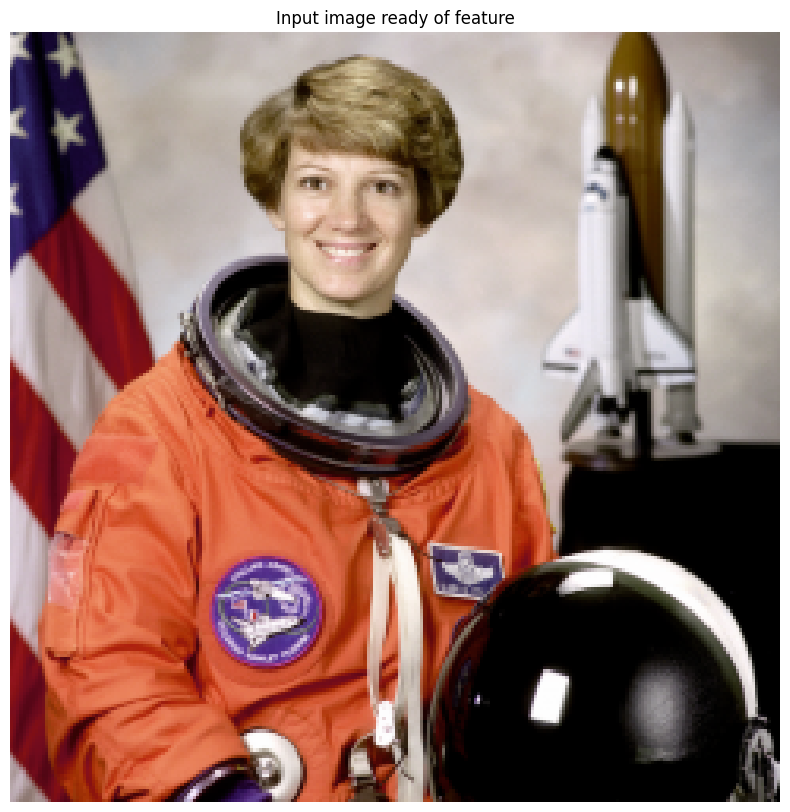

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data, transform # Correcting the import from sklearn to skimage

img_raw = data.astronaut()
img_raw = transform.resize(img_raw, (244, 244))

plt.figure(figsize=(10, 10))
plt.imshow(img_raw, cmap = 'grey')
plt.title("Input image ready of feature")
plt.axis('off')
plt.show()

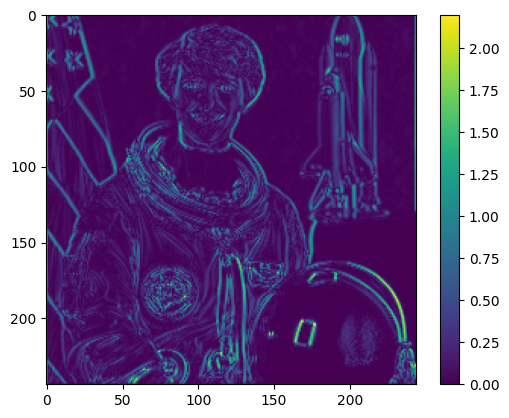

In [30]:
kernel = np.array([[-1,0,1],
                   [-2,0,2],
                   [1,0,-1]])

from scipy.signal import convolve2d
from skimage.color import rgb2gray

# Convert the 3-channel image to grayscale (2-D) for 2D convolution
img_gray = rgb2gray(img_raw)

feature_map = convolve2d(img_gray , kernel ,mode='same' )
plt.imshow(np.absolute(feature_map) , cmap='viridis') # Corrected imshow arguments
plt.colorbar()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step


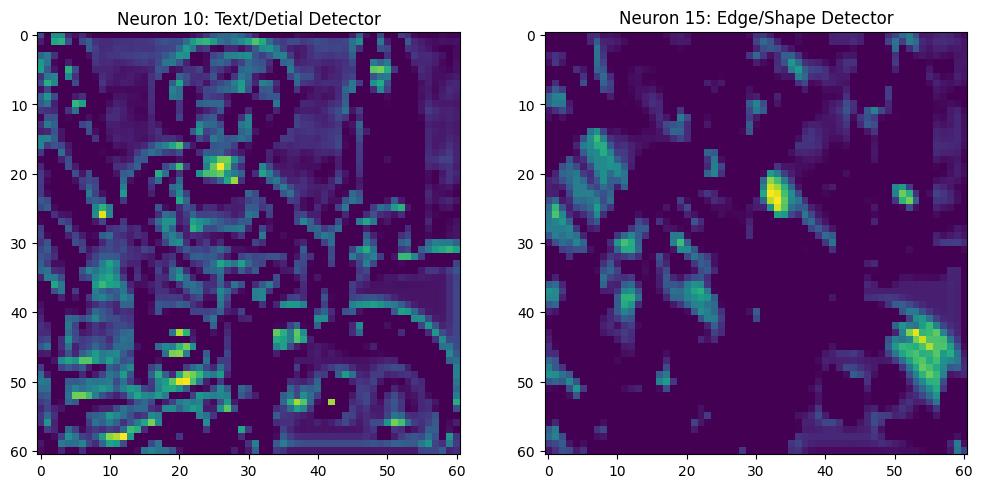

In [31]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16 , preprocess_input
from skimage import data , transform
import numpy as np
import matplotlib.pyplot as plt

model = VGG16(weights='imagenet' , include_top=False)
img_raw = data.astronaut()
astro_resized = transform.resize(img_raw , (244, 244))
x = np.expand_dims(astro_resized*255 , axis=0)
x = preprocess_input(x)
mid_layer_model = tf.keras.Model(inputs=model.input , outputs=model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

fig , ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(mid_features[0,:,:,10], cmap='viridis')
ax[0].set_title("Neuron 10: Text/Detial Detector")
ax[1].imshow(mid_features[0,:,:,15], cmap='viridis')
ax[1].set_title("Neuron 15: Edge/Shape Detector")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


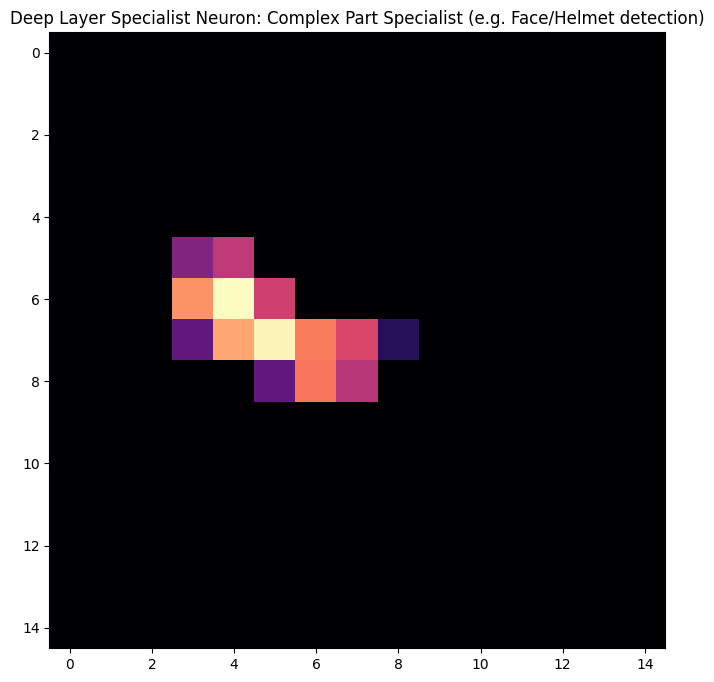

In [33]:
deep_layer_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('block5_conv3').output)
deep_features = deep_layer_model.predict(x)
plt.figure(figsize=(8,8))
plt.imshow(deep_features[0,:,:,3] , cmap='magma')
plt.title("Deep Layer Specialist Neuron: Complex Part Specialist (e.g. Face/Helmet detection)")
plt.show()

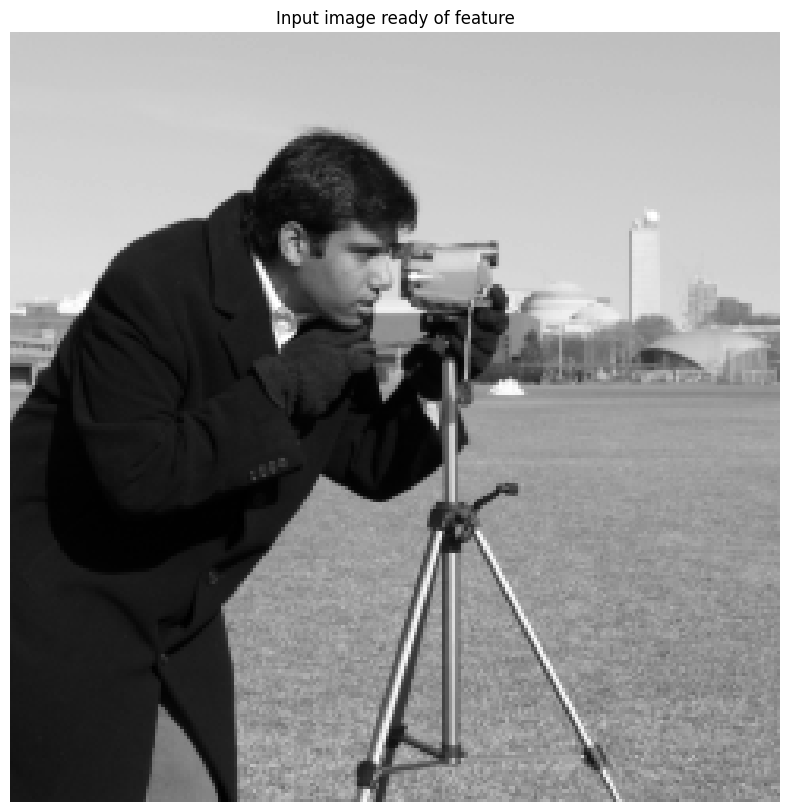

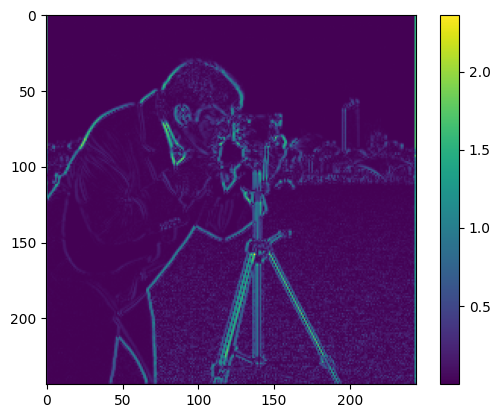

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


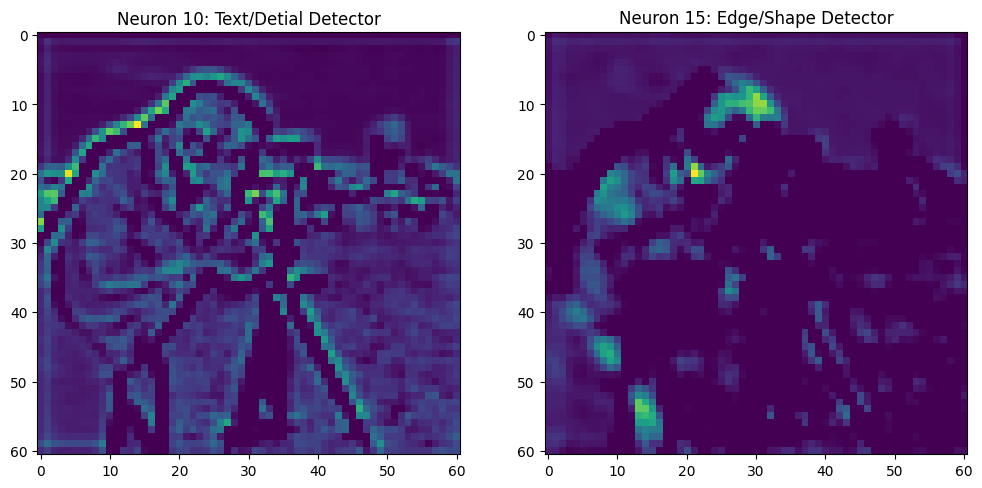

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step


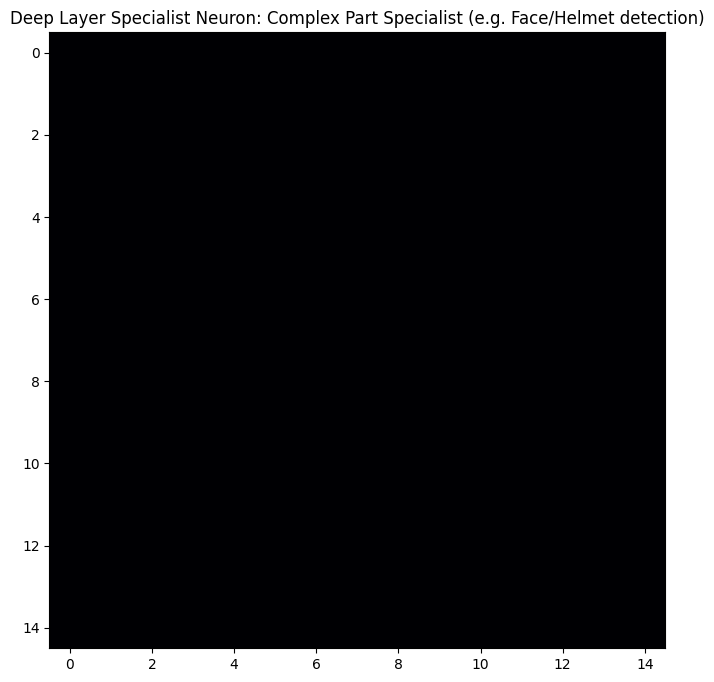

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data, transform # Correcting the import from sklearn to skimage

img_raw = data.camera()
img_raw = transform.resize(img_raw, (244, 244))

plt.figure(figsize=(10, 10))
plt.imshow(img_raw, cmap = 'grey')
plt.title("Input image ready of feature")
plt.axis('off')
plt.show()
kernel = np.array([[-1,0,1],
                   [-2,0,2],
                   [1,0,-1]])

from scipy.signal import convolve2d
from skimage.color import rgb2gray

# The data.camera() image is already grayscale (2-D), so rgb2gray is not needed.
# If you intended to use a color image, you would load data.astronaut() here.
img_gray = img_raw # Use the already grayscale image directly

feature_map = convolve2d(img_gray , kernel ,mode='same' )
plt.imshow(np.absolute(feature_map) , cmap='viridis') # Corrected imshow arguments
plt.colorbar()
plt.show()


import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16 , preprocess_input
from skimage import data , transform
import numpy as np
import matplotlib.pyplot as plt

model = VGG16(weights='imagenet' , include_top=False)
img_raw = data.camera()
astro_resized = transform.resize(img_raw , (244, 244))
# Convert grayscale image to 3 channels for VGG16 model input
astro_resized_rgb = np.stack([astro_resized, astro_resized, astro_resized], axis=-1)
x = np.expand_dims(astro_resized_rgb*255 , axis=0)
x = preprocess_input(x)
mid_layer_model = tf.keras.Model(inputs=model.input , outputs=model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

fig , ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(mid_features[0,:,:,10], cmap='viridis')
ax[0].set_title("Neuron 10: Text/Detial Detector")
ax[1].imshow(mid_features[0,:,:,15], cmap='viridis')
ax[1].set_title("Neuron 15: Edge/Shape Detector")
plt.show()


deep_layer_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('block5_conv3').output)
deep_features = deep_layer_model.predict(x)
plt.figure(figsize=(8,8))
plt.imshow(deep_features[0,:,:,3] , cmap='magma')
plt.title("Deep Layer Specialist Neuron: Complex Part Specialist (e.g. Face/Helmet detection)")
plt.show()

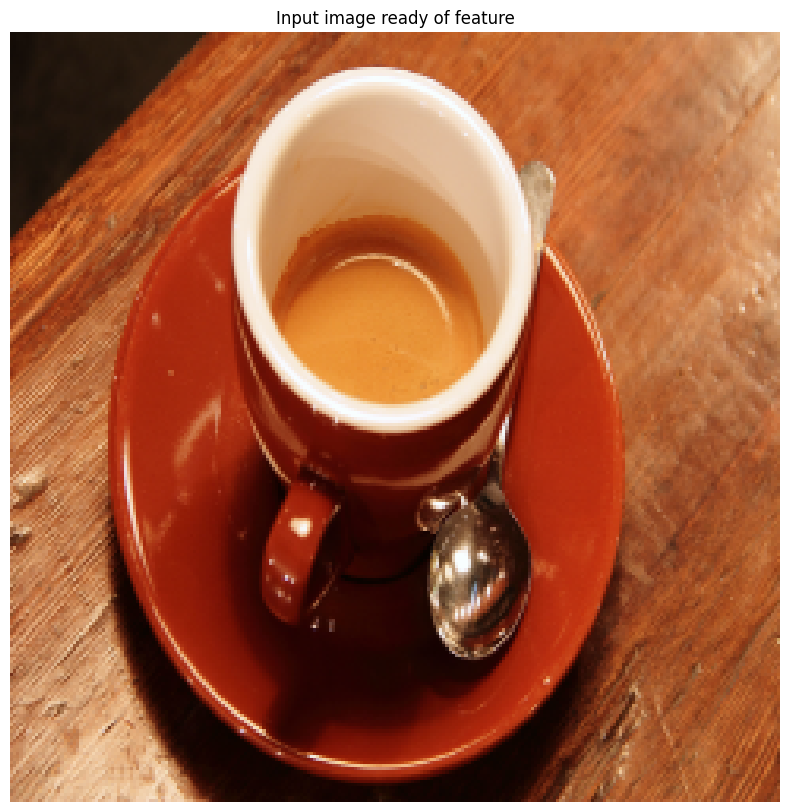

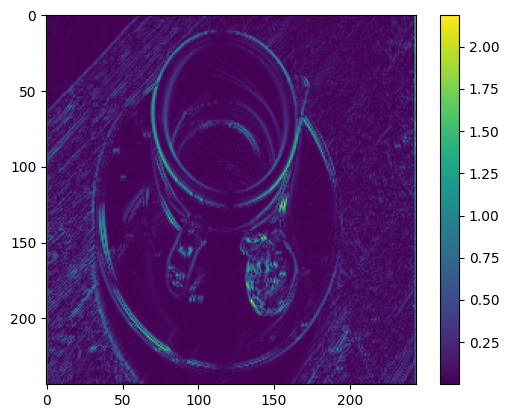

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step


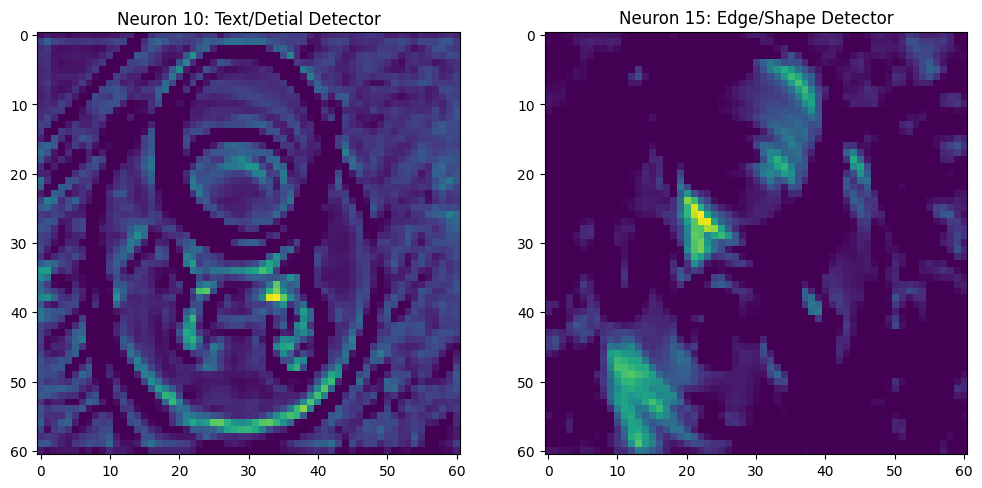

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


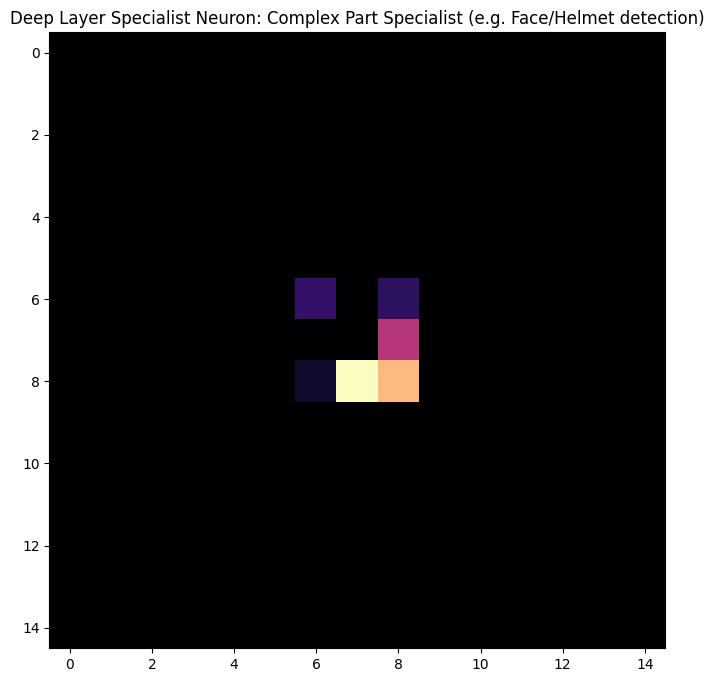

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data, transform # Correcting the import from sklearn to skimage

img_raw = data.coffee()
img_raw = transform.resize(img_raw, (244, 244))

plt.figure(figsize=(10, 10))
plt.imshow(img_raw)
plt.title("Input image ready of feature")
plt.axis('off')
plt.show()
kernel = np.array([[-1,0,1],
                   [-2,0,2],
                   [1,0,-1]])

from scipy.signal import convolve2d
from skimage.color import rgb2gray

# The data.coffee() image is a color image, so it needs to be converted to grayscale for 2D convolution.
img_gray = rgb2gray(img_raw)

feature_map = convolve2d(img_gray , kernel ,mode='same' )
plt.imshow(np.absolute(feature_map) , cmap='viridis') # Corrected imshow arguments
plt.colorbar()
plt.show()


import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16 , preprocess_input
from skimage import data , transform
import numpy as np
import matplotlib.pyplot as plt

model = VGG16(weights='imagenet' , include_top=False)
img_raw = data.coffee()
astro_resized = transform.resize(img_raw , (244, 244))
# Convert color image to 3 channels for VGG16 model input
x = np.expand_dims(astro_resized*255 , axis=0)
x = preprocess_input(x)
mid_layer_model = tf.keras.Model(inputs=model.input , outputs=model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

fig , ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(mid_features[0,:,:,10], cmap='viridis')
ax[0].set_title("Neuron 10: Text/Detial Detector")
ax[1].imshow(mid_features[0,:,:,15], cmap='viridis')
ax[1].set_title("Neuron 15: Edge/Shape Detector")
plt.show()


deep_layer_model = tf.keras.Model(inputs=model.input, outputs=model.get_layer('block5_conv3').output)
deep_features = deep_layer_model.predict(x)
plt.figure(figsize=(8,8))
plt.imshow(deep_features[0,:,:,3] , cmap='magma')
plt.title("Deep Layer Specialist Neuron: Complex Part Specialist (e.g. Face/Helmet detection)")
plt.show()